In [1]:
import os
import decode
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

start_iter = 200 
end_iter = 800
frames_per_iter = 250

start_frame = start_iter * frames_per_iter
end_frame = (end_iter+1) * frames_per_iter

#hesslab_input_file = r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2h - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_PALM_LOCALIZATIONS_WITH_BOTH_XY_AND_Z_DRIFT_CORRECTION_ASCII.hdf5'
hesslab_input_file =  r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2h - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_PALM_LOCALIZATIONS_WITH_BOTH_XY_AND_Z_DRIFT_CORRECTION_ASCII.txt.hdf5'
#hesslab_input_file = r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
#hesslab_input_file = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/IDL Peak Finder/2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
emitters=decode.EmitterSet.load(hesslab_input_file)
# filter based on start and end frame
print('Hesslab Emitters',emitters)
emitters = emitters[(emitters.frame_ix >= start_frame) & (emitters.frame_ix < end_frame)]
print('Hesslab Emitters',emitters)



c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hesslab Emitters EmitterSet
::num emitters: 41540233
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 289749
::spanned volume: [ 8.82217e-01  5.06720e-04 -9.55214e+02] - [800.    800.    992.622]
Hesslab Emitters EmitterSet
::num emitters: 18283369
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 200249
::spanned volume: [ 1.17762e+00  5.06720e-04 -9.25156e+02] - [799.996 799.996 980.35 ]


In [19]:
out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'
fig_path = os.path.join(out_path, 'figures-2025-07-31')

C:\Users\bnort\AppData\Local\Temp\ipykernel_32812\3538920061.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_32812\3538920061.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::su

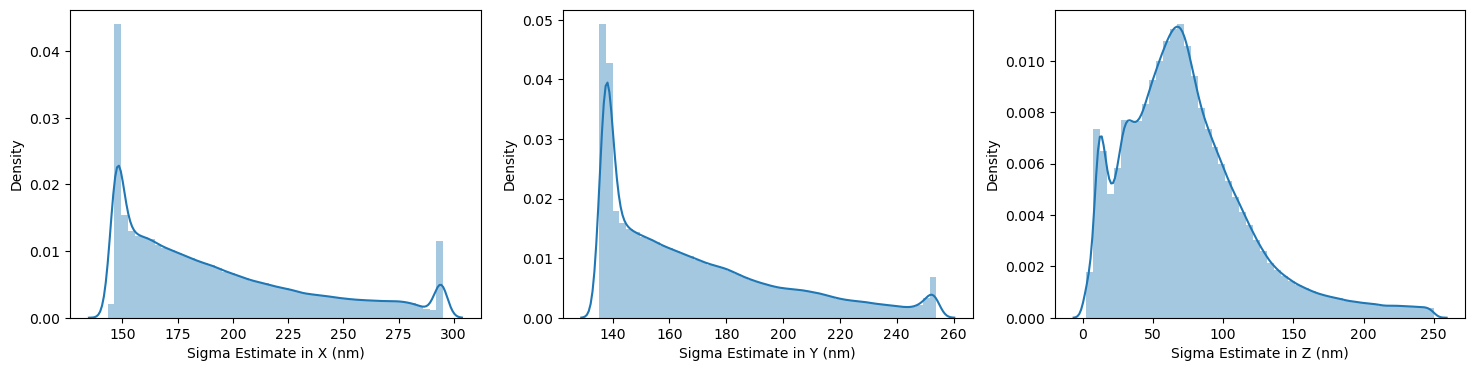

In [2]:
sub_sample = 25

plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

In [3]:
print(emitters)
sigma_x_high_threshold = 250
sigma_y_high_threshold = 250
sigma_z_high_threshold = 200
prob_threshold = 0.0
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    ]

print(emitters_filtered)



EmitterSet
::num emitters: 18283369
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 200249
::spanned volume: [ 1.17762e+00  5.06720e-04 -9.25156e+02] - [799.996 799.996 980.35 ]
0,1 0 500
EmitterSet
::num emitters: 15369428
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 200249
::spanned volume: [ 1.17762e+00  5.06720e-04 -5.12409e+02] - [799.996 799.996 865.271]


In [4]:
emitters_filtered.xyz_px[:,2].min(), emitters_filtered.xyz_px[:,2].max()

emitters_filtered.xyz_px[:,2] = -emitters_filtered.xyz_px[:,2]

emitters_filtered.xyz_px[:,2].min(), emitters_filtered.xyz_px[:,2].max()

(tensor(-865.2710, dtype=torch.float64), tensor(512.4090, dtype=torch.float64))

In [10]:
def render_emitters(emitters):

    fig, axs = plt.subplots(2, 2, figsize=(24, 12), sharex='col',
                            gridspec_kw={'height_ratios': [1, 1200 / 20000]})

    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                            contrast=15.25).render(emitters, emitters.xyz_nm[:, 2], ax=axs[0, 0])
    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], plot_axis=(0, 2)).render(emitters, ax=axs[1, 0])


    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                            contrast=1.25).render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
        render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[1, 1])

    #plt.savefig(os.path.join(fig_path, rf'fitting\rendered.png'), dpi=300, bbox_inches='tight')
    #plt.show()

    return fig

def render_emitters(emitters):

    fig, axs = plt.subplots(2, 1, figsize=(8, 12))

    px_size = 10
    
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-1200, 1200], colextent=[-1200, 1200], plot_axis=(0, 1),
                            contrast=15.25).render(emitters, emitters.xyz_nm[:, 2], ax=axs[0])

    
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], plot_axis=(0, 2)).render(emitters, ax=axs[1])
    '''
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                            contrast=1.25).render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
        render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[1, 1])
    '''
    #plt.savefig(os.path.join(fig_path, rf'fitting\rendered.png'), dpi=300, bbox_inches='tight')
    #plt.show()

    return fig

In [14]:

emitters_filtered.xyz_px = emitters_filtered.xyz_px[:, [1, 0, 2]] # swap x and y for rendering

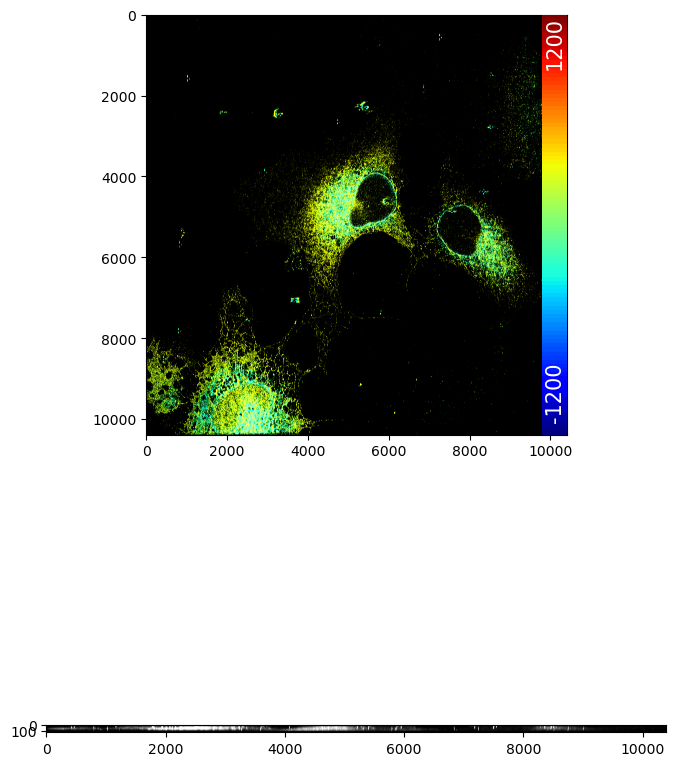

In [15]:
fig = render_emitters(emitters_filtered)

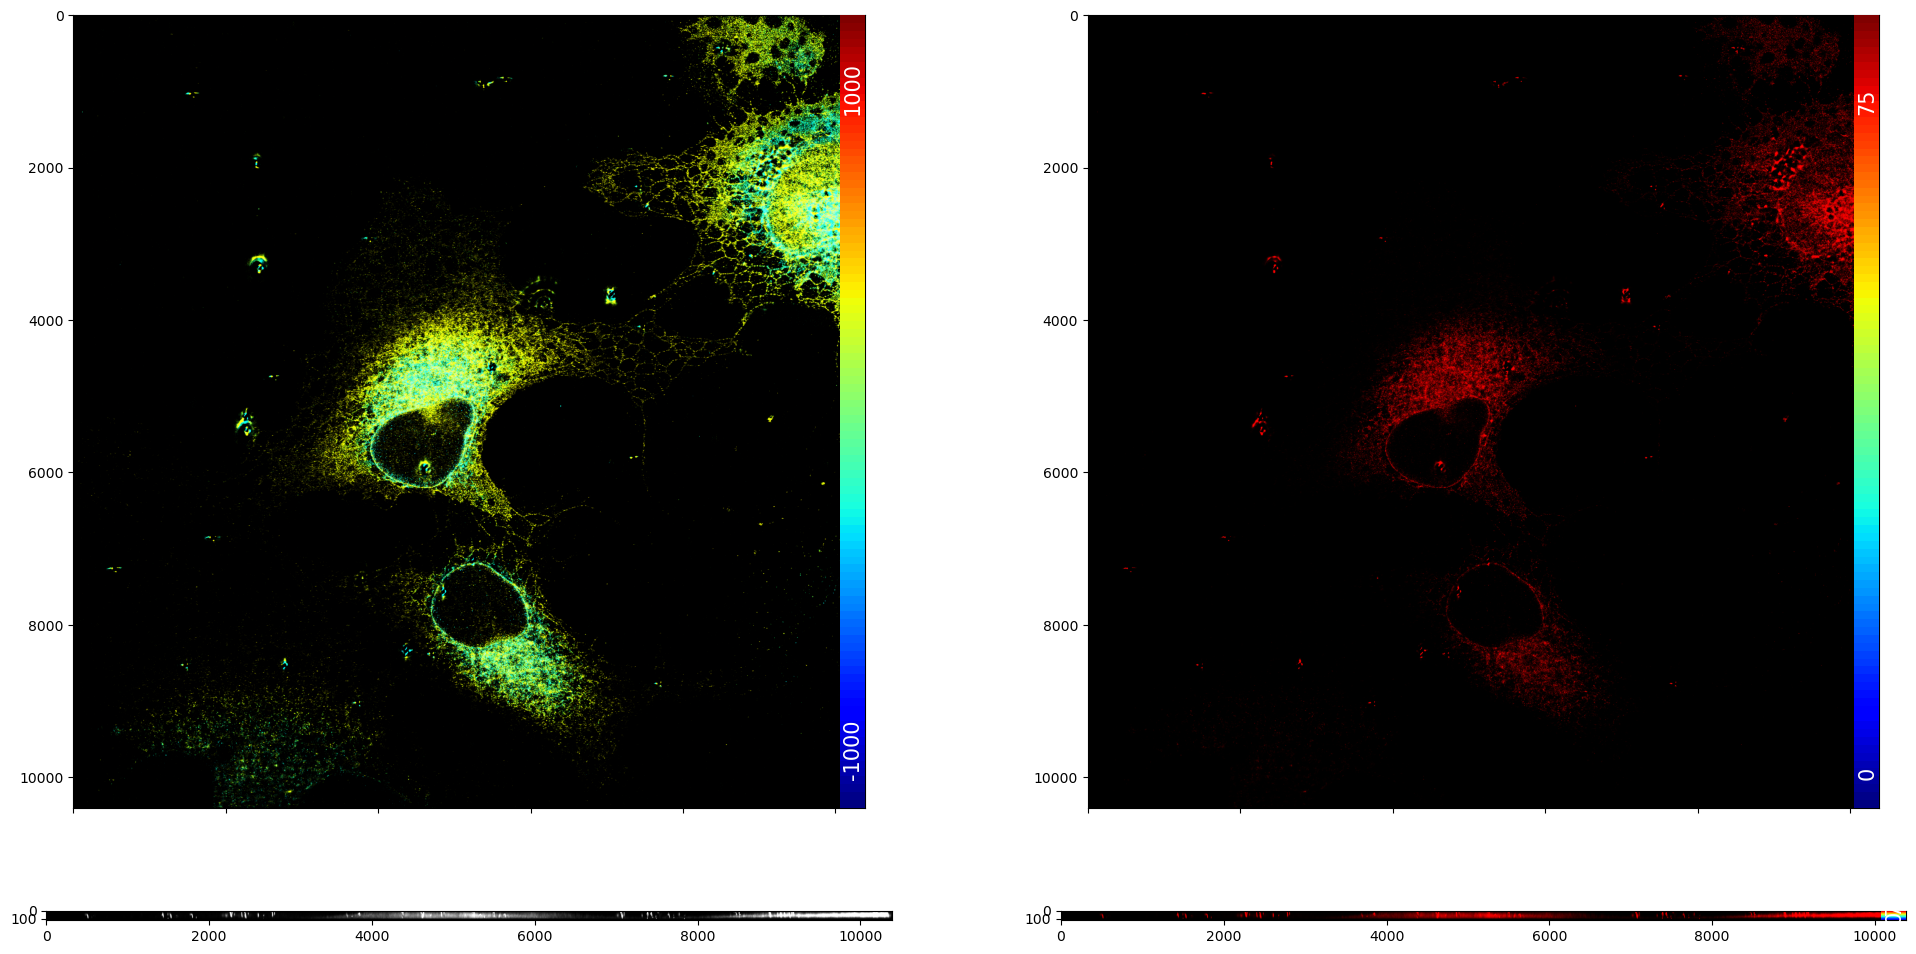

In [6]:
fig = render_emitters(emitters_filtered)

<AxesSubplot:>

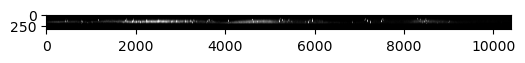

In [16]:
fig, axs = plt.subplots(1, 1, figsize=(6, 12))
#temp = temp[:100000]  # Limit to 10,000 emitters for rendering
px_size = 10.

decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=100,
                        zextent=[-1600, 1600], plot_axis=(0, 2)).render(emitters_filtered, ax=axs)#[1])

(320, 10400)


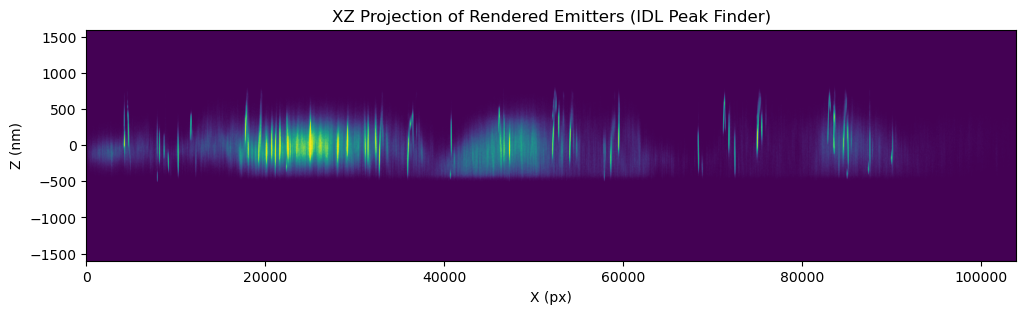

In [21]:
img = axs.images[0].get_array()

print(img.shape)


plt.figure(figsize=(12, 3))  # big figure to see better

xmin = 0
xmax = img.shape[1] * px_size
ymin = -1600
ymax = 1600

plt.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],  # stretch vertically: map 12 rows into 200 units
    aspect='auto',             # allow non-square pixels
    interpolation='bilinear'   # smooth interpolation
)

plt.title('XZ Projection of Rendered Emitters (IDL Peak Finder)')
plt.xlabel('X (px)')
plt.ylabel('Z (nm)')

plt.savefig(os.path.join(fig_path, rf'xz_hesslab_rendered.png'), dpi=300, bbox_inches='tight')

plt.show()


In [7]:
ax = fig.axes[0]
img = ax.images[0].get_array()

print(img.dtype, img.shape)

float64 (10400, 10385, 3)


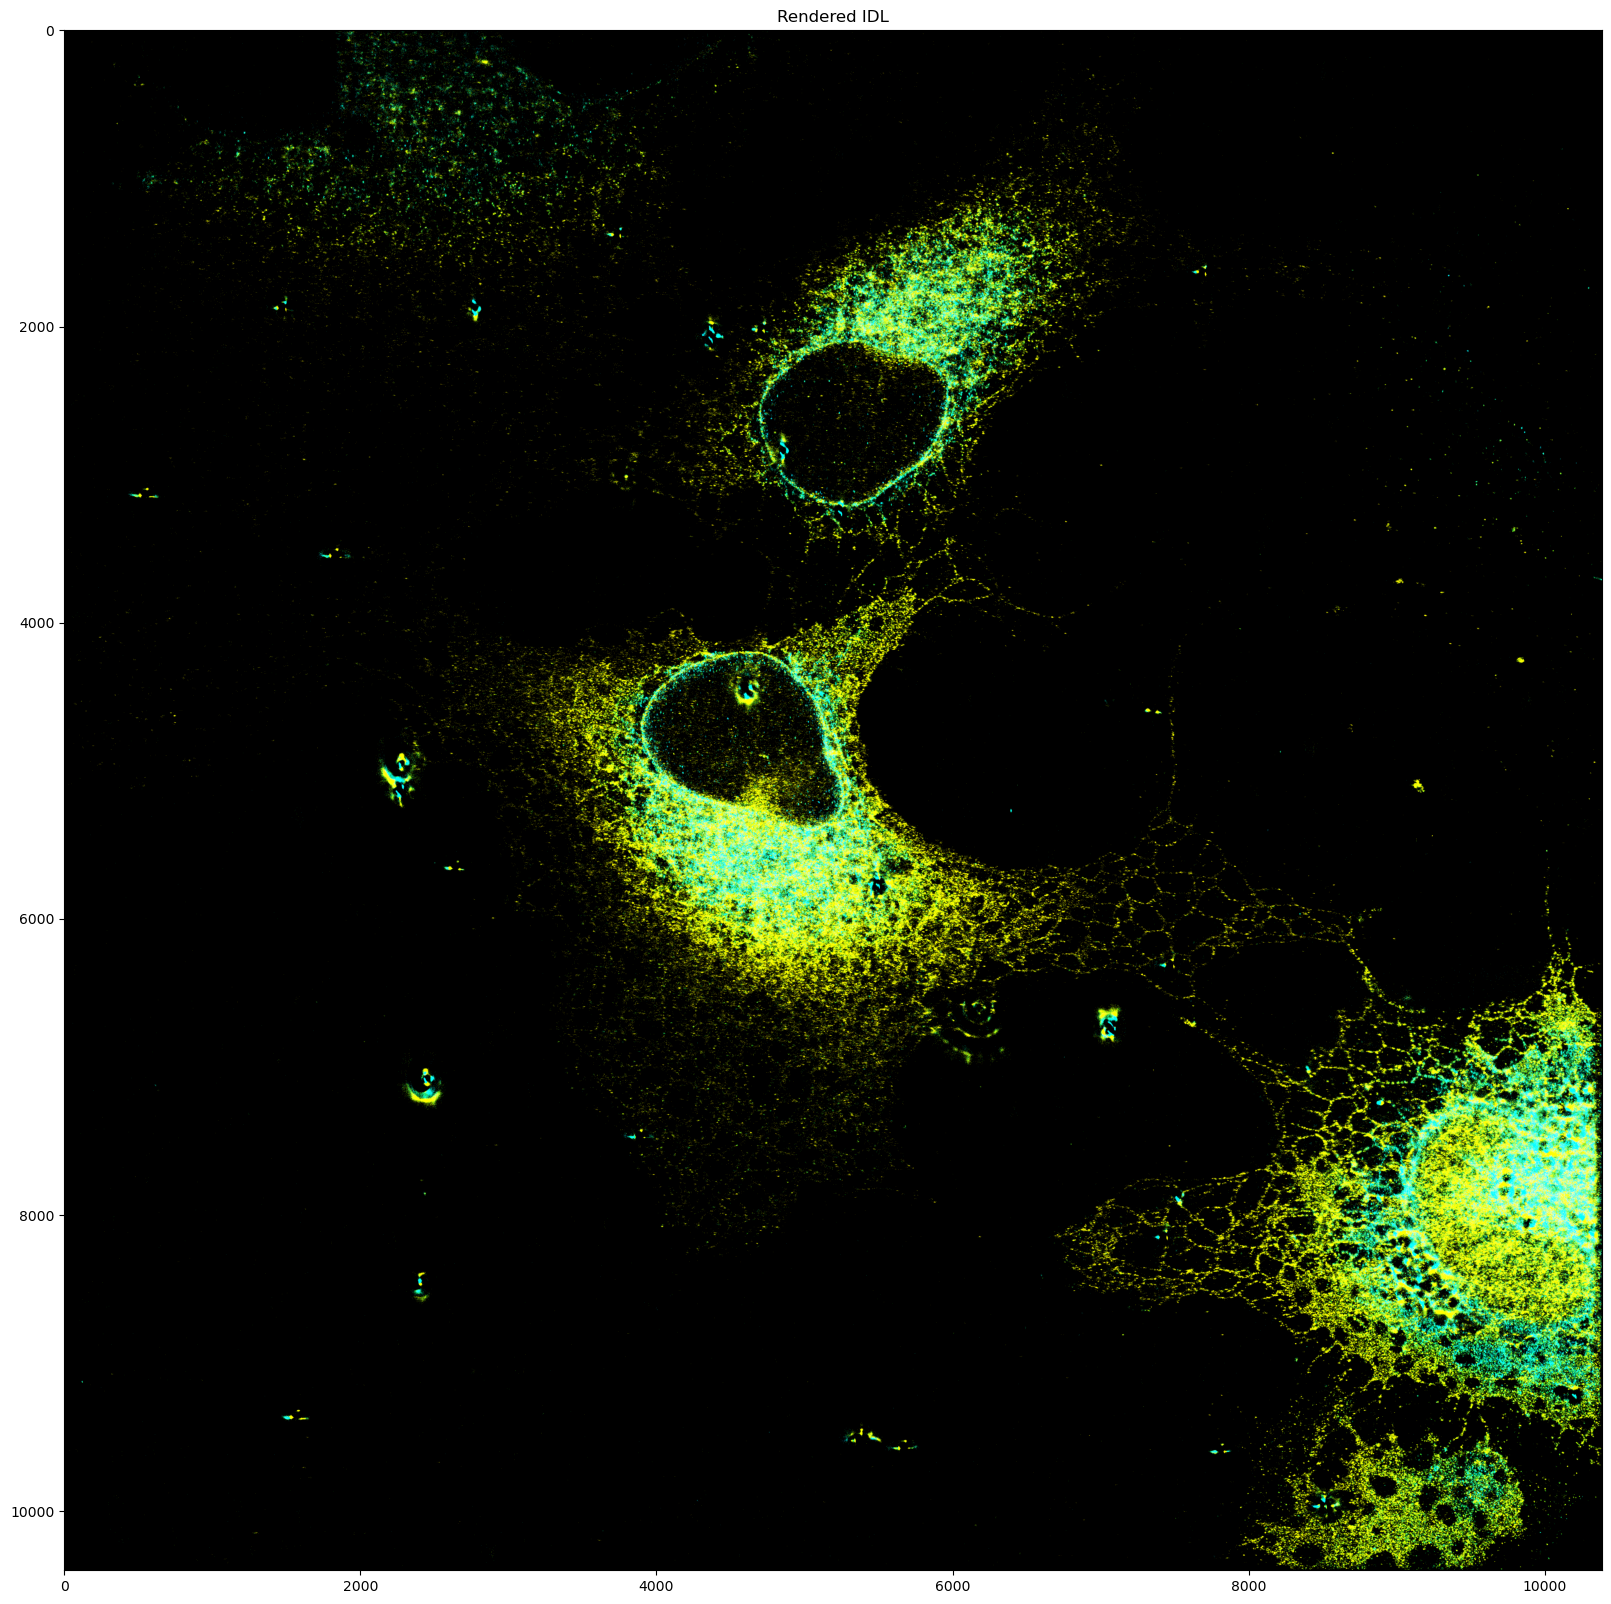

In [8]:
import numpy as np
import matplotlib.pyplot as plt
imgt = img #np.transpose(img, (1, 0, 2))
imgt = imgt[::-1, :, :]
fig = plt.figure(figsize=(20, 20))
plt.imshow(imgt, cmap='gray')
plt.title('Rendered IDL')
fig_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2\figures-2025-07-16'
plt.savefig(os.path.join(fig_path, rf'rendered_idl.png'), dpi=300, bbox_inches='tight')

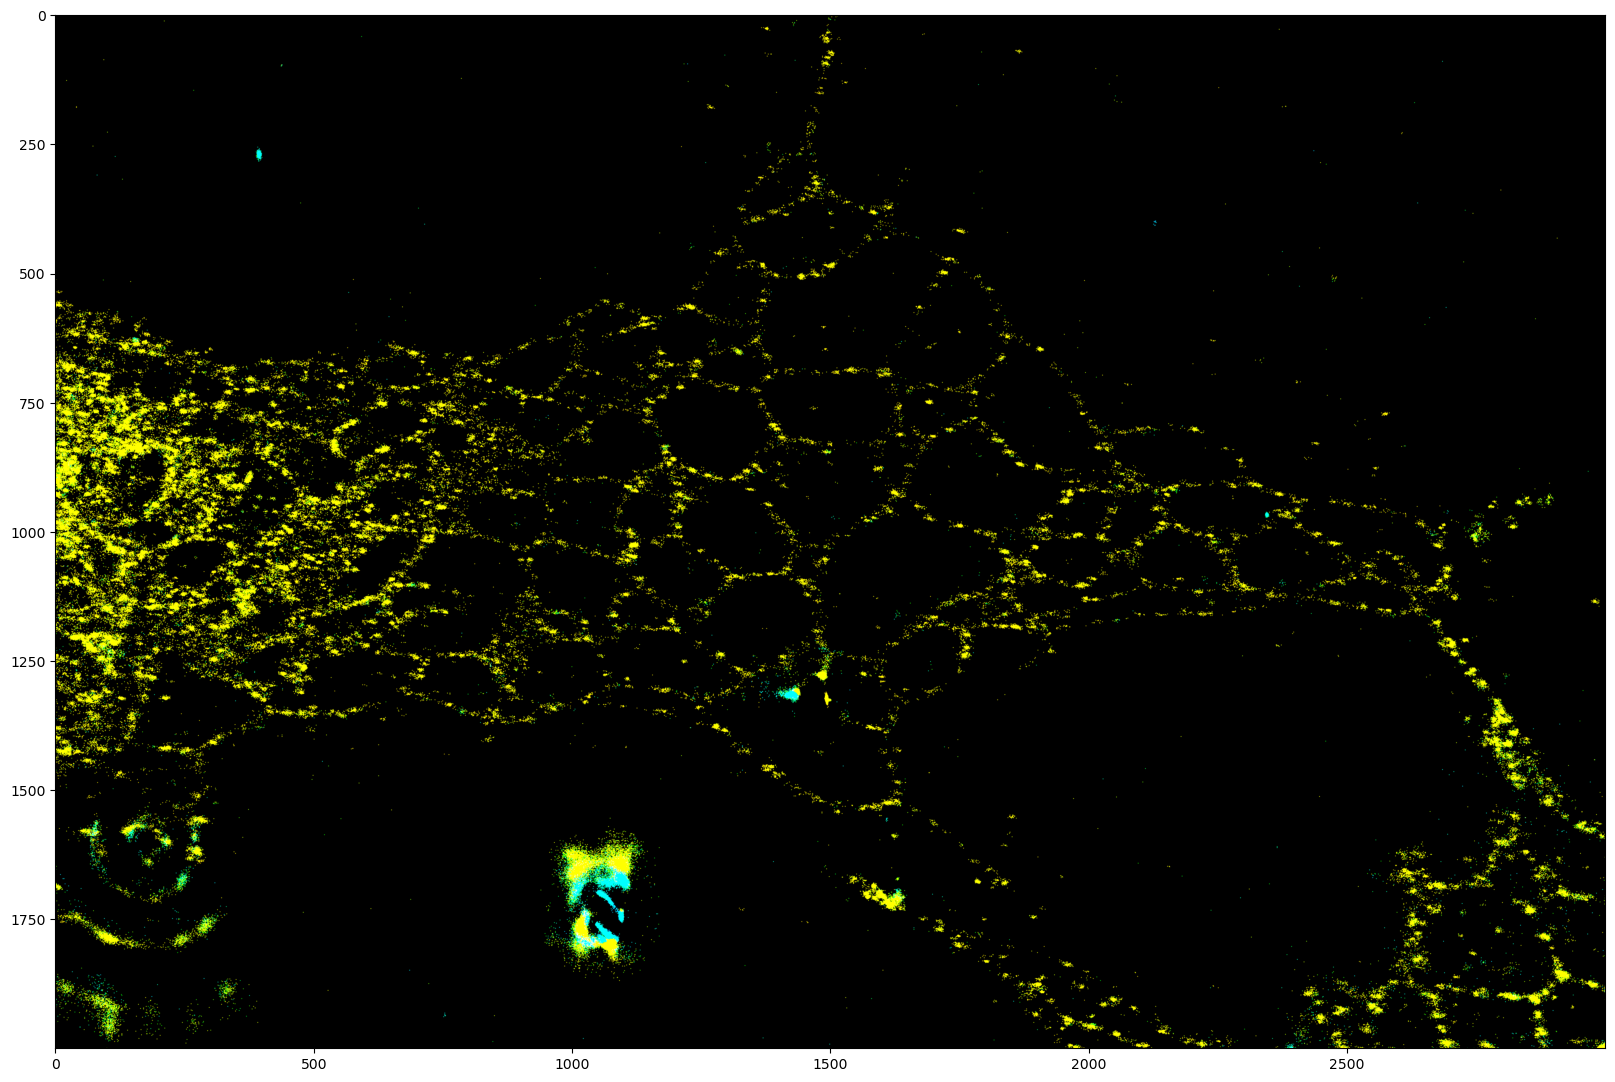

In [18]:
imgt_cropped = imgt[5000:7000, 6000:9000, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt_cropped, cmap='gray')

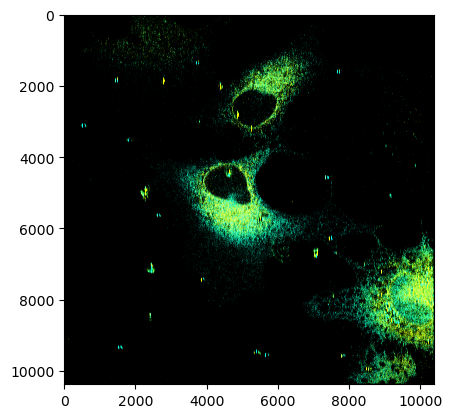

In [7]:
import numpy as np
import matplotlib.pyplot as plt
imgt = img #np.transpose(img, (1, 0, 2))
imgt = imgt[::-1, :, :]
plt.imshow(imgt, cmap='gray')

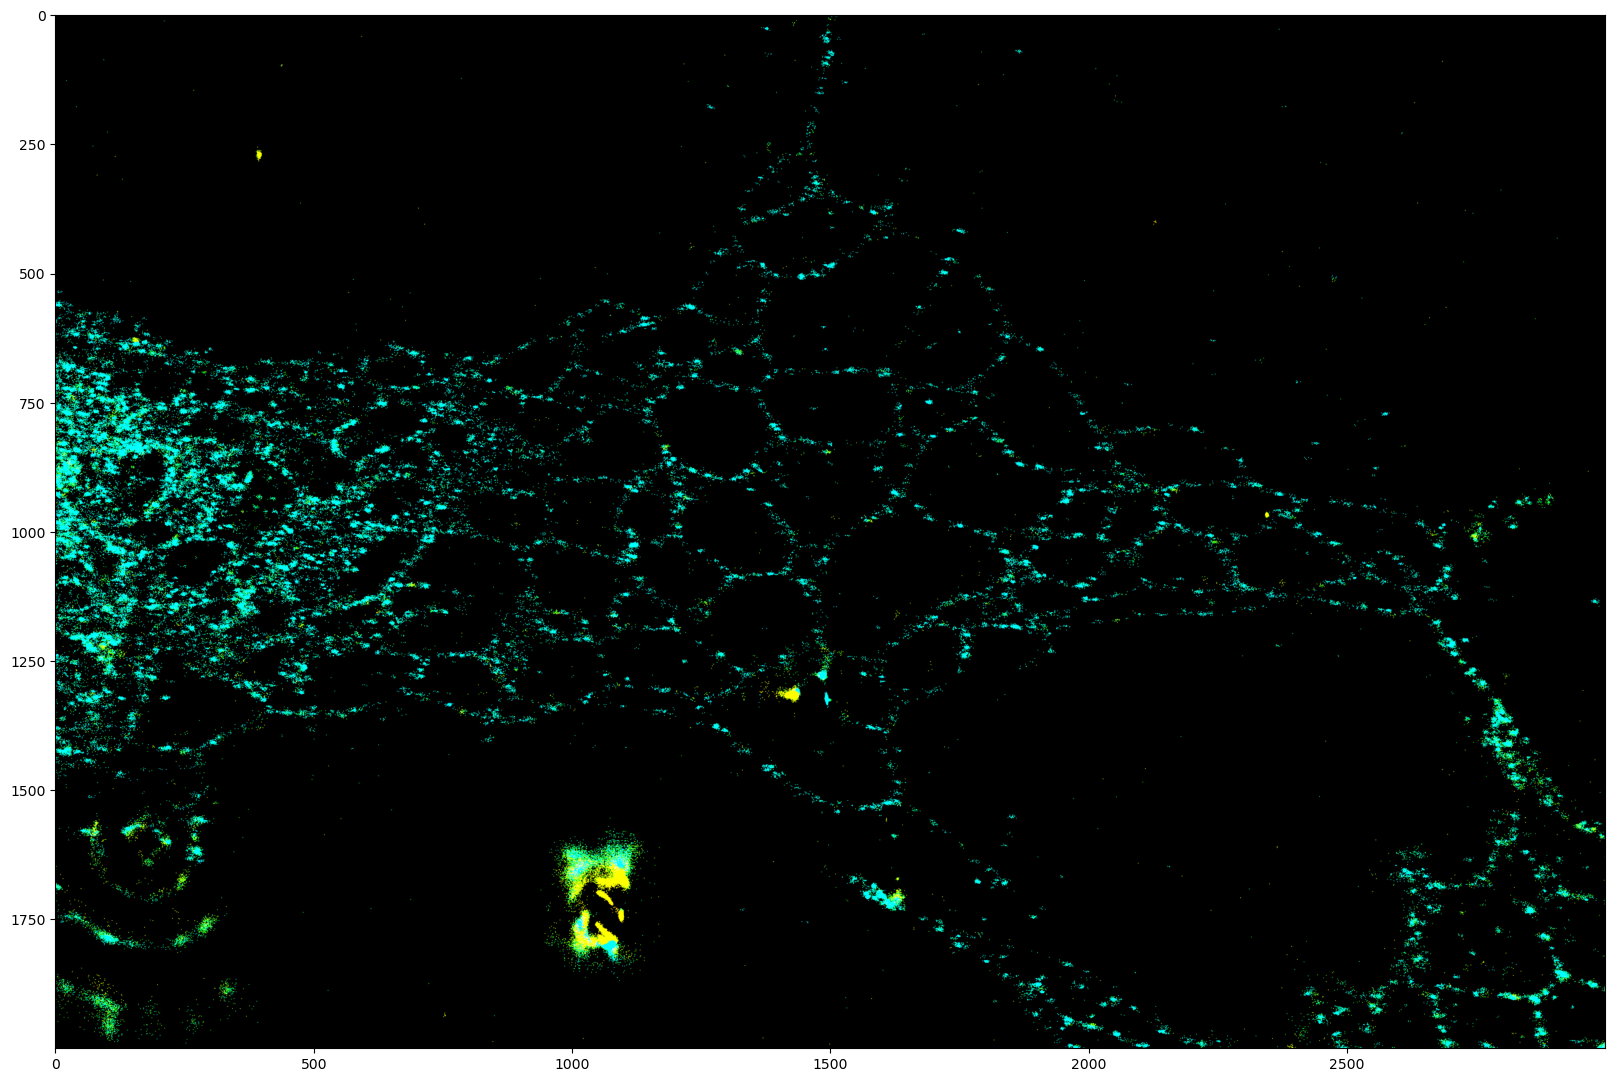

In [18]:
imgt_cropped = imgt[5000:7000, 6000:9000, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt_cropped, cmap='gray')

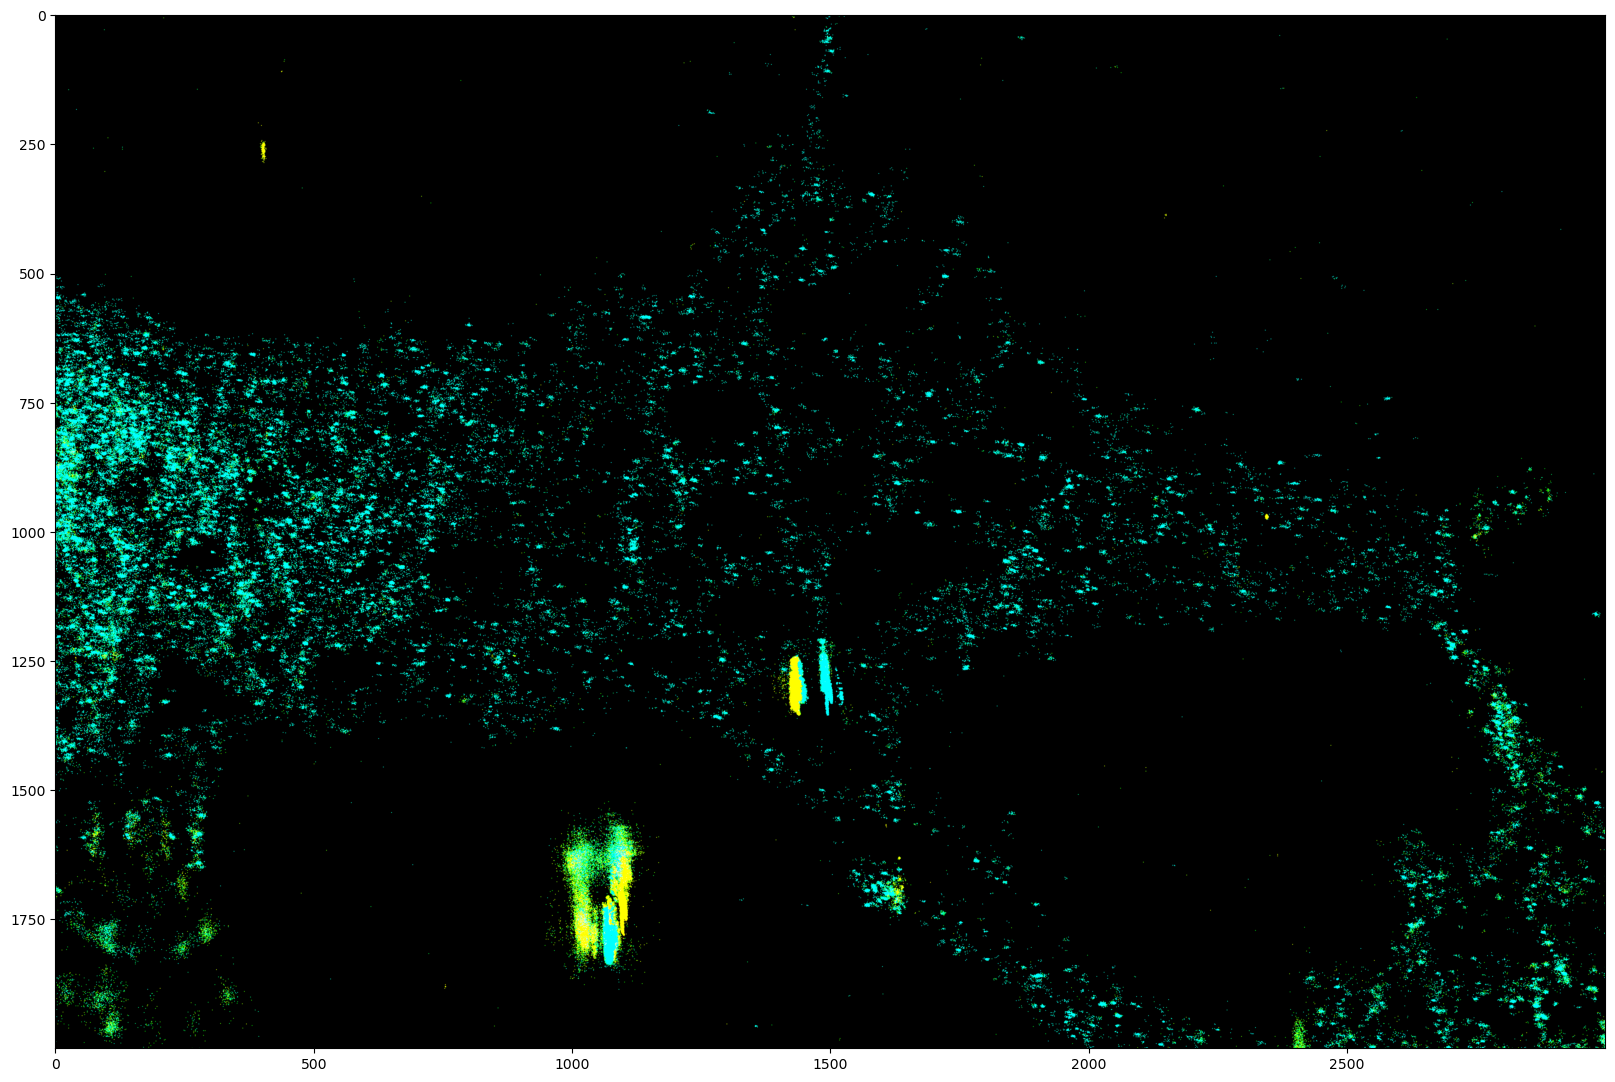

In [8]:
imgt_cropped = imgt[5000:7000, 6000:9000, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt_cropped, cmap='gray')